# Tabular Playground Series 2026 | Irrigation Need Prediction

---

| | |
|---|---|
| **Metric** | Balanced Accuracy |
| **Target** | `Irrigation_Need` | Low / Medium / High |
| **Strategy** | LightGBM + XGBoost + CatBoost → Optuna Tuning → Soft-Vote Ensemble |

---

## Notebook Structure

1. Install & Imports
2. Data Loading & Overview
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Model Definitions
7. Cross-Validation Utilities
8. Evaluation Metric Helpers
9. Hyperparameter Tuning (Optuna)
10. Full Training with Tuned Parameters
11. Ensembling
12. Generate Test Predictions
13. Submission
14. Bonus | Feature Importance, SHAP & Error Analysis

---
## Section 0 | Install & Imports

Install the required packages if they are not already present, then import all dependencies used throughout the notebook.

In [1]:
!pip install -q lightgbm xgboost catboost optuna shap imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import gc
import os
import time
import json

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV

# Boosting
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Class imbalance
from imblearn.over_sampling import SMOTE

# SHAP (optional)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# Reproducibility
SEED       = 42
N_FOLDS    = 3
N_TRIALS   = 20         # Optuna trials per model
INPUT_DIR  = Path(".")   # adjust if running on Kaggle: Path("/kaggle/input/...")
OUTPUT_DIR = Path(".")

np.random.seed(SEED)

# Colour palette: Low / Medium / High
PALETTE = ["#2ecc71", "#f39c12", "#e74c3c"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.1)

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Section 1 | Data Loading & Overview

Load the train and test CSVs, inspect shapes, data types, missing values, and the distribution of the target variable.

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")

print("\nFirst 5 rows of train:")
train.head()

Train shape : (630000, 21)
Test  shape : (270000, 20)

First 5 rows of train:


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
print("Data types & non-null counts:")
train.info()

# Missing values
miss_train = train.isnull().sum()
miss_test  = test.isnull().sum()
print("\nMissing values | Train:\n", miss_train[miss_train > 0])
print("\nMissing values | Test:\n",  miss_test[miss_test > 0])

# Target distribution
TARGET      = "Irrigation_Need"
label_order = ["Low", "Medium", "High"]

dist = train[TARGET].value_counts(normalize=True).reindex(label_order) * 100
print(f"\nTarget distribution (%):\n{dist.round(2)}")

Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   6300

---
## Section 2 | Exploratory Data Analysis

Visual inspection of:
- Target class distribution (count and percentage)
- Numerical feature distributions split by target class
- Correlation heatmap
- Box plots for the features most correlated with the target

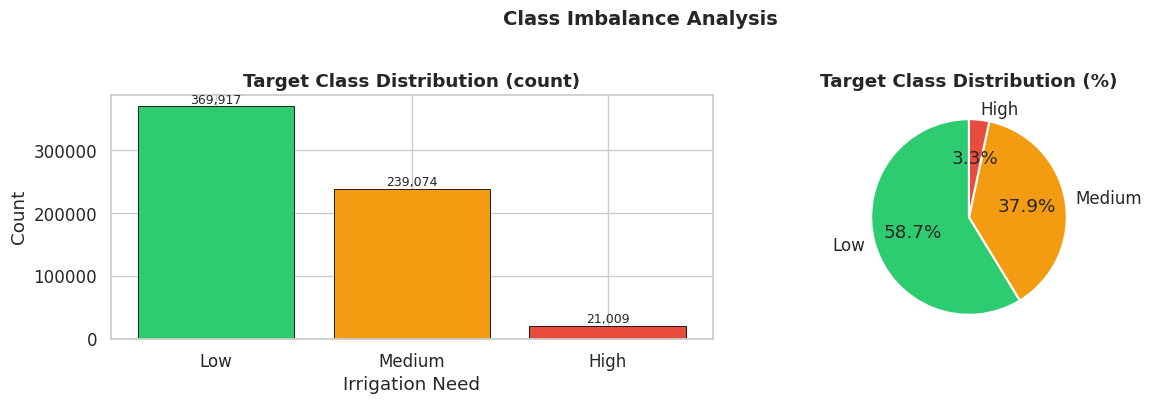

Insight: Class imbalance is present | Balanced Accuracy is the right metric.


In [4]:
# 2-a  Target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = train[TARGET].value_counts().reindex(label_order)
axes[0].bar(label_order, counts, color=PALETTE, edgecolor="black", linewidth=0.6)
axes[0].set_title("Target Class Distribution (count)", fontweight="bold")
axes[0].set_xlabel("Irrigation Need")
axes[0].set_ylabel("Count")
for bar, cnt in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=9)

axes[1].pie(counts, labels=label_order, autopct="%1.1f%%",
            colors=PALETTE, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Target Class Distribution (%)", fontweight="bold")

plt.suptitle("Class Imbalance Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Insight: Class imbalance is present | Balanced Accuracy is the right metric.")

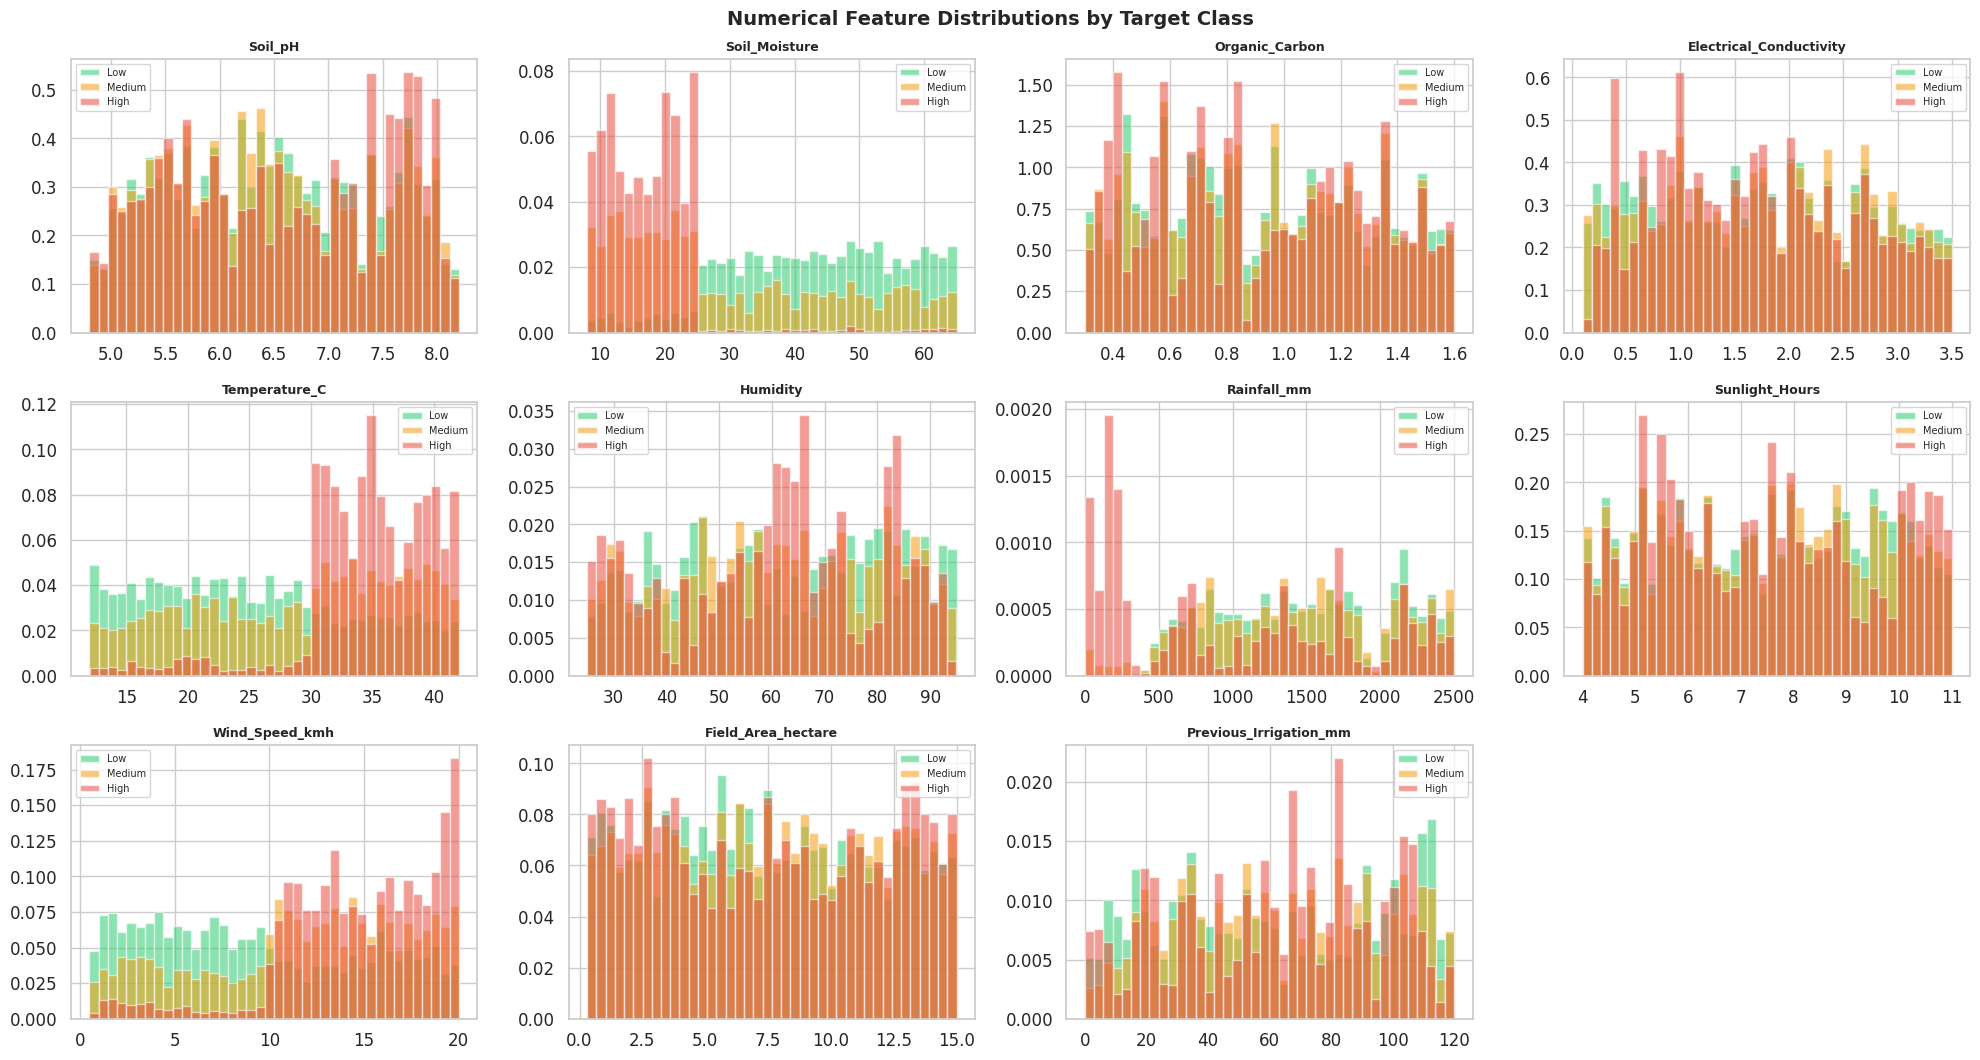

In [5]:
# 2-b  Numerical feature distributions
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["id"]]

fig, axes = plt.subplots(4, 4, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    for label, colour in zip(label_order, PALETTE):
        subset = train.loc[train[TARGET] == label, col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.55, color=colour, label=label, density=True)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Numerical Feature Distributions by Target Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_num_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

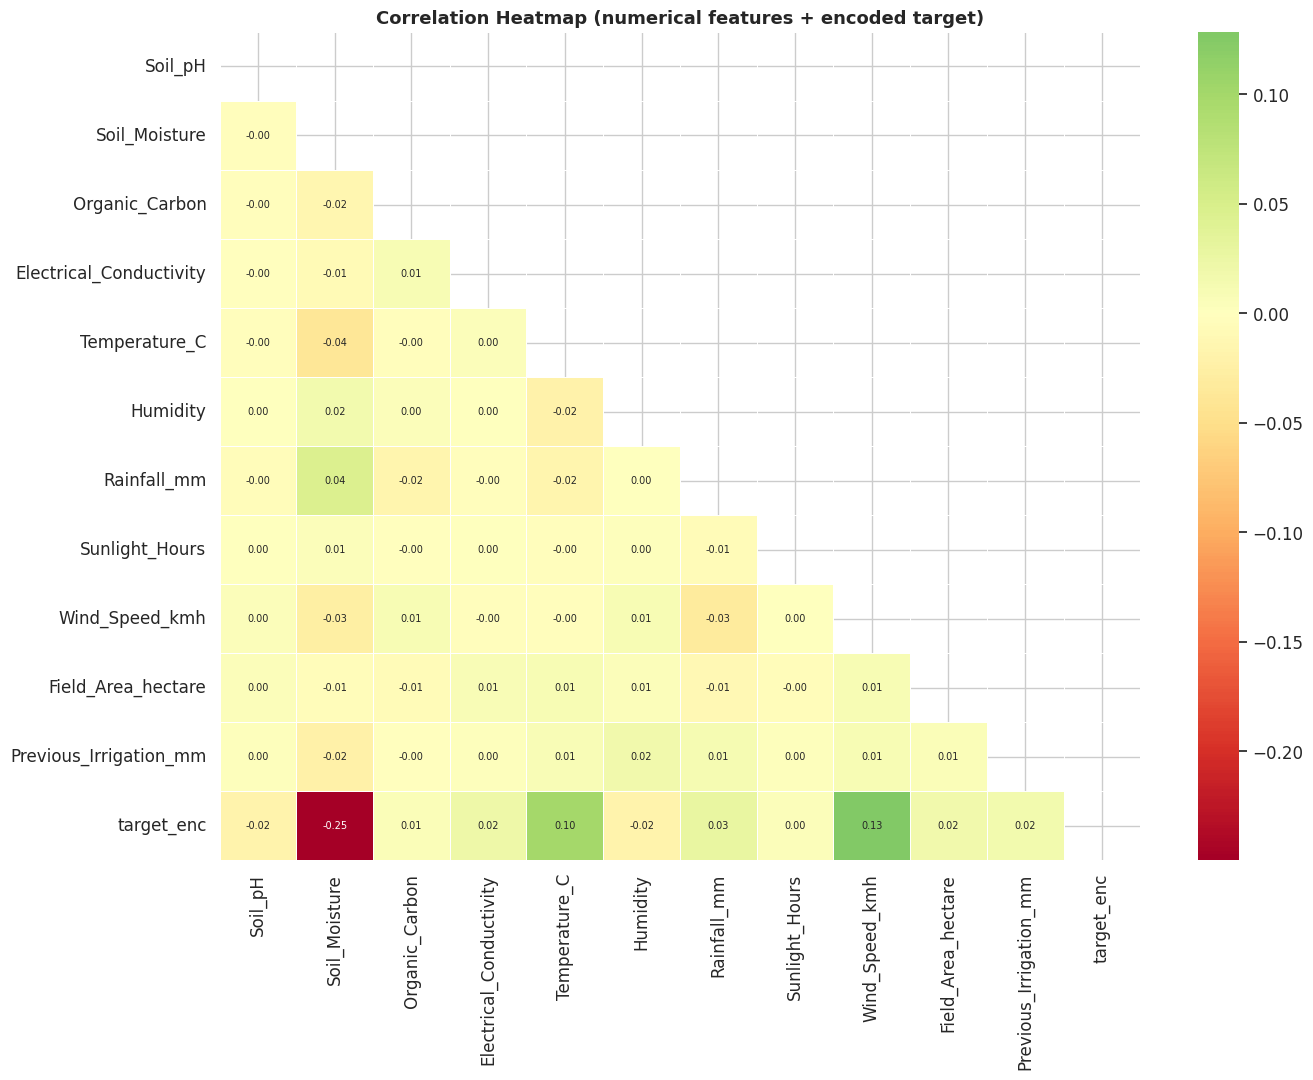

In [6]:
# 2-c  Correlation heatmap
le_tmp = LabelEncoder()
tmp_df = train[num_cols].copy()
tmp_df["target_enc"] = le_tmp.fit_transform(train[TARGET])

corr = tmp_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap (numerical features + encoded target)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

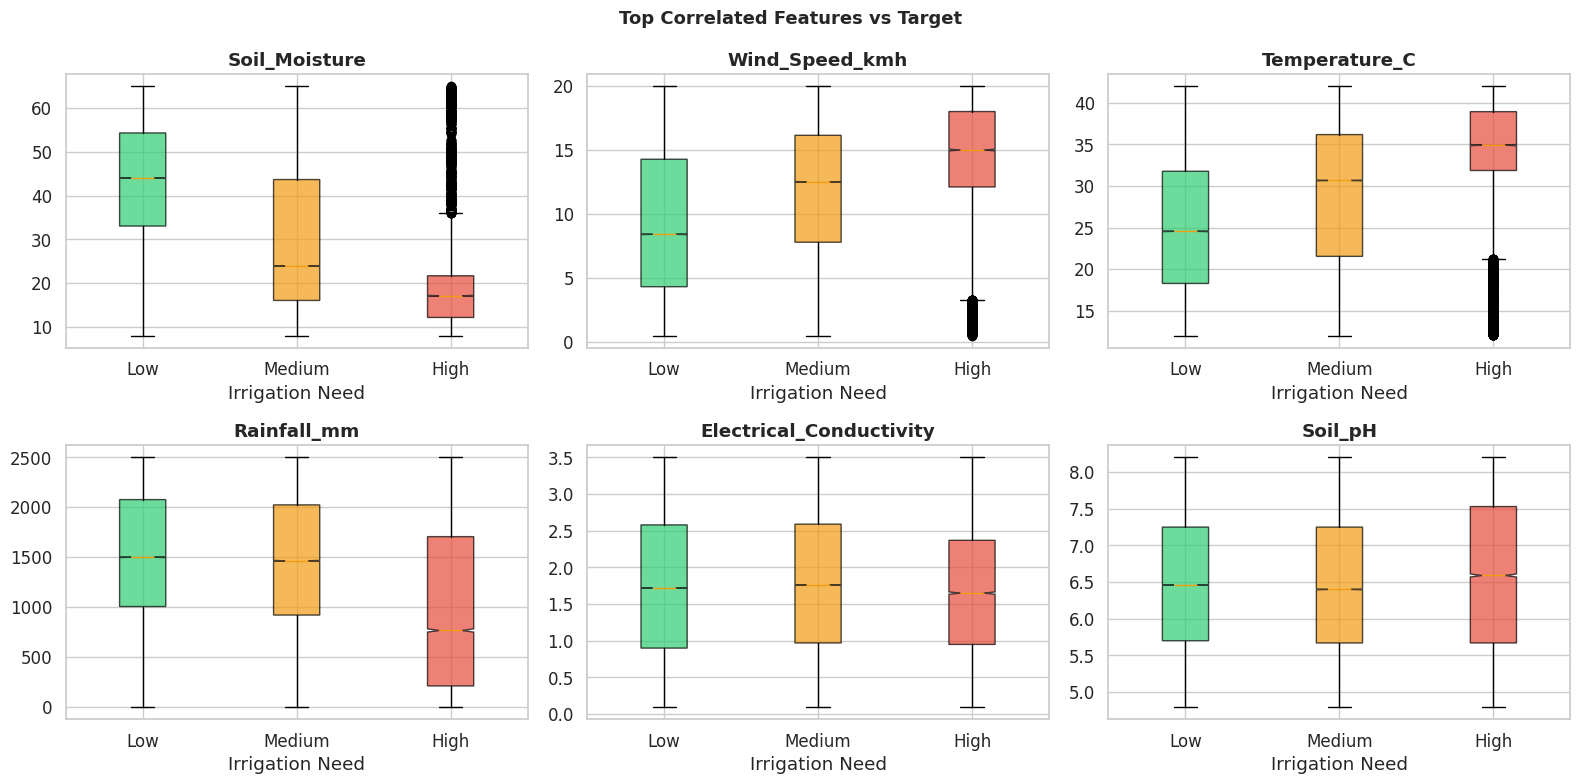


Key Insights:
  - Features most correlated with target: ['Soil_Moisture', 'Wind_Speed_kmh', 'Temperature_C', 'Rainfall_mm', 'Electrical_Conductivity', 'Soil_pH']
  - Class imbalance needs to be handled with class_weight or SMOTE.
  - Categorical features (Soil_Type, Crop_Type, etc.) need proper encoding.


In [7]:
# 2-d  Box plots: top correlated features vs target
top_feats = (corr["target_enc"].abs()
             .drop("target_enc")
             .sort_values(ascending=False)
             .head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top_feats):
    data_to_plot = [train.loc[train[TARGET] == lbl, col].dropna().values
                    for lbl in label_order]
    bp = axes[i].boxplot(data_to_plot, labels=label_order,
                         patch_artist=True, notch=True)
    for patch, colour in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("Irrigation Need")

plt.suptitle("Top Correlated Features vs Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_boxplots_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey Insights:")
print("  - Features most correlated with target:", top_feats)
print("  - Class imbalance needs to be handled with class_weight or SMOTE.")
print("  - Categorical features (Soil_Type, Crop_Type, etc.) need proper encoding.")

---
## Section 3 | Data Preprocessing

Steps performed:
1. Identify categorical and numerical columns
2. Combine train and test for consistent preprocessing
3. Impute missing values | median for numerics, mode for categoricals
4. Label-encode all categorical columns
5. Encode the target variable and split back into train/test

In [8]:
# Column type definitions
CAT_COLS = ["Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
            "Irrigation_Type", "Water_Source", "Mulching_Used", "Region"]

NUM_COLS = ["Soil_pH", "Soil_Moisture", "Organic_Carbon",
            "Electrical_Conductivity", "Temperature_C", "Humidity",
            "Rainfall_mm", "Sunlight_Hours", "Wind_Speed_kmh",
            "Field_Area_hectare", "Previous_Irrigation_mm"]

# Combine for consistent preprocessing
combined = pd.concat([train.drop(columns=[TARGET]), test], axis=0, ignore_index=True)
print(f"Combined shape: {combined.shape}")

# Missing value imputation
for col in NUM_COLS:
    median_val = combined[col].median()
    combined[col].fillna(median_val, inplace=True)

for col in CAT_COLS:
    mode_val = combined[col].mode()[0]
    combined[col].fillna(mode_val, inplace=True)

print("Missing values filled (median for numeric, mode for categorical).")

# Ordinal encoding for LGBM / XGB (CatBoost handles categoricals natively)
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    label_encoders[col] = le

print("Categorical columns label-encoded.")

# Encode target
TARGET_MAP = {"Low": 0, "Medium": 1, "High": 2}
INV_MAP    = {v: k for k, v in TARGET_MAP.items()}
train_y    = train[TARGET].map(TARGET_MAP).values
print(f"Target encoded: {TARGET_MAP}")

# Split back
n_train = len(train)
train_X = combined.iloc[:n_train].drop(columns=["id"]).copy()
test_X  = combined.iloc[n_train:].drop(columns=["id"]).copy()

print(f"\nTrain features shape : {train_X.shape}")
print(f"Test  features shape : {test_X.shape}")

Combined shape: (900000, 20)
Missing values filled (median for numeric, mode for categorical).
Categorical columns label-encoded.
Target encoded: {'Low': 0, 'Medium': 1, 'High': 2}

Train features shape : (630000, 19)
Test  features shape : (270000, 19)


---
## Section 4 | Feature Engineering

The `engineer_features` function creates the following groups of features:

| Group | Features |
|---|---|
| **Physics-inspired indices** | Moisture Index, Evaporation Proxy, Water Need Ratio, Dryness Index, Soil Stress, Heat Load, Water Balance |
| **Interaction features** | CropSeason, SoilIrrType, CropStageRegion |
| **Binned features** | TempBin, MoistureBin, RainfallBin |
| **Log transforms** | log of right-skewed features |
| **Polynomial features** | Temperature × Humidity, Soil Moisture × pH |

In [9]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    eps = 1e-6  # avoid division by zero

    # Physics-inspired indices
    df["Moisture_Index"]    = df["Soil_Moisture"] / (df["Temperature_C"] + eps)
    df["Evaporation_Proxy"] = (df["Temperature_C"] * df["Sunlight_Hours"]
                               / (df["Humidity"] + eps))
    df["Water_Need_Ratio"]  = (df["Previous_Irrigation_mm"]
                               / (df["Rainfall_mm"] + eps))
    df["Dryness_Index"]     = (df["Temperature_C"] - df["Humidity"]
                               + df["Wind_Speed_kmh"]) / (df["Rainfall_mm"] + eps)
    df["Soil_Stress"]       = df["Electrical_Conductivity"] * df["Soil_pH"]
    df["Heat_Load"]         = df["Temperature_C"] * df["Sunlight_Hours"]
    df["Water_Balance"]     = df["Rainfall_mm"] - df["Previous_Irrigation_mm"]

    # Interaction features
    df["CropSeason"]      = df["Crop_Type"].astype(str) + "_" + df["Season"].astype(str)
    df["SoilIrrType"]     = df["Soil_Type"].astype(str) + "_" + df["Irrigation_Type"].astype(str)
    df["CropStageRegion"] = (df["Crop_Type"].astype(str) + "_"
                             + df["Crop_Growth_Stage"].astype(str) + "_"
                             + df["Region"].astype(str))

    for col in ["CropSeason", "SoilIrrType", "CropStageRegion"]:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    # Binning
    df["TempBin"]     = pd.cut(df["Temperature_C"],  bins=5, labels=False)
    df["MoistureBin"] = pd.cut(df["Soil_Moisture"],  bins=5, labels=False)
    df["RainfallBin"] = pd.cut(df["Rainfall_mm"],    bins=5, labels=False)

    # Log transforms (right-skewed features)
    for col in ["Rainfall_mm", "Previous_Irrigation_mm", "Field_Area_hectare",
                "Water_Need_Ratio", "Evaporation_Proxy"]:
        df[f"log_{col}"] = np.log1p(np.abs(df[col]))

    # Polynomial interactions
    df["TempHumidity_product"] = df["Temperature_C"] * df["Humidity"]
    df["SoilMoist_pH_product"] = df["Soil_Moisture"] * df["Soil_pH"]

    return df


train_X = engineer_features(train_X)
test_X  = engineer_features(test_X)

print("Feature engineering complete.")
print(f"  Train shape after FE : {train_X.shape}")
print(f"  Test  shape after FE : {test_X.shape}")

FEATURES = train_X.columns.tolist()

Feature engineering complete.
  Train shape after FE : (630000, 39)
  Test  shape after FE : (270000, 39)


---
## Section 5 | Model Definitions

Base hyperparameter configurations are defined for three gradient boosting frameworks:

- **LightGBM** | fast, leaf-wise tree growth with `is_unbalance=True` for class imbalance
- **XGBoost** | depth-wise tree growth with `multi:softprob` objective
- **CatBoost** | native categorical support with `auto_class_weights="Balanced"`

These configurations serve as starting points before Optuna tuning in Section 8.

In [10]:
# Class weights for balanced training
class_counts  = np.bincount(train_y)
n_samples     = len(train_y)
n_classes     = len(class_counts)
class_weights = {i: n_samples / (n_classes * class_counts[i]) for i in range(n_classes)}
cw_array      = np.array([class_weights[y] for y in train_y])
print(f"Class weights: {class_weights}")

# LightGBM base parameters
lgbm_params_base = {
    "objective"       : "multiclass",
    "num_class"       : 3,
    "metric"          : "multi_logloss",
    "boosting_type"   : "gbdt",
    "num_leaves"      : 63,
    "learning_rate"   : 0.05,
    "max_depth"       : -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq"    : 5,
    "min_child_samples": 20,
    "lambda_l1"       : 0.1,
    "lambda_l2"       : 0.1,
    "is_unbalance"    : True,
    "verbose"         : -1,
    "seed"            : SEED,
}

# XGBoost base parameters
xgb_params_base = {
    "objective"        : "multi:softprob",
    "num_class"        : 3,
    "eval_metric"      : "mlogloss",
    "max_depth"        : 6,
    "learning_rate"    : 0.05,
    "n_estimators"     : 1000,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "use_label_encoder": False,
    "verbosity"        : 0,
    "random_state"     : SEED,
}

# CatBoost base parameters
catboost_params_base = {
    "iterations"           : 1000,
    "learning_rate"        : 0.05,
    "depth"                : 6,
    "loss_function"        : "MultiClass",
    "eval_metric"          : "TotalF1",
    "auto_class_weights"   : "Balanced",
    "random_seed"          : SEED,
    "verbose"              : 0,
    "early_stopping_rounds": 50,
}

print("Base model configurations defined.")

Class weights: {0: np.float64(0.5676949153458749), 1: np.float64(0.8783891180136694), 2: np.float64(9.995716121662145)}
Base model configurations defined.


---
## Section 6 | Cross-Validation Utilities

Stratified K-Fold cross-validation (k=5) is used for all models. Each function returns:
- **OOF predictions** | out-of-fold probability arrays of shape `(N, 3)`
- **Fold scores** | balanced accuracy per fold

In [11]:
SKF = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def run_lgbm_cv(X, y, params, early_stop=100):
    """Stratified K-Fold CV with LightGBM. Returns OOF predictions and fold scores."""
    oof_preds   = np.zeros((len(y), 3))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(SKF.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        cb     = lgb.early_stopping(early_stop, verbose=False)
        cb_log = lgb.log_evaluation(period=-1)

        model = lgb.train(
            params, dtrain,
            num_boost_round=5000,
            valid_sets=[dval],
            callbacks=[cb, cb_log],
        )

        oof_preds[val_idx] = model.predict(X_val)
        preds_class = np.argmax(oof_preds[val_idx], axis=1)
        score = balanced_accuracy_score(y_val, preds_class)
        fold_scores.append(score)
        print(f"  Fold {fold+1}/{N_FOLDS} | Balanced Acc: {score:.5f}  "
              f"(best iter: {model.best_iteration})")

    print(f"  Mean +/- Std: {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}")
    return oof_preds, fold_scores


def run_xgb_cv(X, y, params, early_stop=100):
    """Stratified K-Fold CV with XGBoost."""
    oof_preds   = np.zeros((len(y), 3))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(SKF.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = xgb.XGBClassifier(**params, early_stopping_rounds=early_stop)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        oof_preds[val_idx] = model.predict_proba(X_val)
        preds_class = np.argmax(oof_preds[val_idx], axis=1)
        score = balanced_accuracy_score(y_val, preds_class)
        fold_scores.append(score)
        print(f"  Fold {fold+1}/{N_FOLDS} | Balanced Acc: {score:.5f}")

    print(f"  Mean +/- Std: {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}")
    return oof_preds, fold_scores


def run_catboost_cv(X, y, params):
    """Stratified K-Fold CV with CatBoost."""
    oof_preds   = np.zeros((len(y), 3))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(SKF.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  use_best_model=True, verbose=0)

        oof_preds[val_idx] = model.predict_proba(X_val)
        preds_class = np.argmax(oof_preds[val_idx], axis=1)
        score = balanced_accuracy_score(y_val, preds_class)
        fold_scores.append(score)
        print(f"  Fold {fold+1}/{N_FOLDS} | Balanced Acc: {score:.5f}")

    print(f"  Mean +/- Std: {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}")
    return oof_preds, fold_scores


print("CV utility functions defined.")

CV utility functions defined.


---
## Section 7 | Evaluation Metric Helpers

The primary metric is **Balanced Accuracy**, which is the average recall per class | ideal for imbalanced datasets. The `evaluate_oof` helper also prints a full classification report and plots the confusion matrix.

In [12]:
def evaluate_oof(y_true, oof_probs, model_name="Model"):
    """Compute and display balanced accuracy and confusion matrix for OOF predictions."""
    y_pred = np.argmax(oof_probs, axis=1)
    ba     = balanced_accuracy_score(y_true, y_pred)

    print(f"\n{model_name}  |  OOF Balanced Accuracy = {ba:.5f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_order)}")

    fig, ax = plt.subplots(figsize=(6, 5))
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} | Confusion Matrix (OOF)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"cm_{model_name.replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    return ba


print("Evaluation helpers defined.")

Evaluation helpers defined.


---
## Section 8 | Hyperparameter Tuning with Optuna

Each model has a dedicated Optuna objective function that performs a mini cross-validation on a subset of hyperparameter candidates. The TPE sampler is used for efficient Bayesian optimisation.

**Search spaces:**

| Model | Key Parameters Searched |
|---|---|
| LightGBM | `num_leaves`, `learning_rate`, `max_depth`, `feature_fraction`, `bagging_fraction`, `lambda_l1/l2` |
| XGBoost | `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `gamma`, `reg_alpha/lambda` |
| CatBoost | `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`, `border_count` |

In [13]:
!pip install optuna-integration[lightgbm]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 5.4 MB/s eta 0:00:00


In [14]:
def run_cv(model_type, params):
    cv_scores = []

    for tr_idx, val_idx in SKF.split(train_X, train_y):
        X_tr, X_val = train_X.iloc[tr_idx], train_X.iloc[val_idx]
        y_tr, y_val = train_y[tr_idx], train_y[val_idx]

        if model_type == "lgbm":
            dtrain = lgb.Dataset(X_tr, label=y_tr)
            dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

            model = lgb.train(
                params,
                dtrain,
                num_boost_round=500,
                valid_sets=[dval],
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(period=-1)
                ],
            )

            preds = model.predict(X_val)
            preds = np.argmax(preds, axis=1)

        elif model_type == "xgb":
            model = xgb.XGBClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False,
                early_stopping_rounds=50
            )
            preds = model.predict(X_val)

        elif model_type == "cat":
            model = CatBoostClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=(X_val, y_val),
                use_best_model=True,
                verbose=0
            )
            preds = model.predict(X_val).ravel()

        score = balanced_accuracy_score(y_val, preds)
        cv_scores.append(score)

    return np.mean(cv_scores)

In [16]:
# ── 10-minute Optuna tuning ───────────────────────────────────────────────────
# Budget: ~10 min total across 3 models
# Strategy: 2-fold CV · 20 trials · hard round caps · aggressive pruning

N_TRIALS_TUNE = 20                  # per model  (60 studies total)
SKF_TUNE      = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)


def _score_fold(model_type, params, X_tr, y_tr, X_val, y_val, trial=None, fold=0):
    if model_type == "lgbm":
        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        model  = lgb.train(
            params, dtrain,
            num_boost_round=400,            # hard cap
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(25, verbose=False),
                       lgb.log_evaluation(period=-1)],
        )
        score = balanced_accuracy_score(y_val,
                    np.argmax(model.predict(X_val), axis=1))

    elif model_type == "xgb":
        model = xgb.XGBClassifier(**params, early_stopping_rounds=25)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        score = balanced_accuracy_score(y_val, model.predict(X_val))

    else:  # catboost
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  use_best_model=True, verbose=0)
        score = balanced_accuracy_score(y_val, model.predict(X_val).ravel())

    if trial is not None:
        trial.report(score, fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return score


def _make_objective(model_type, space_fn):
    def objective(trial):
        params = space_fn(trial)
        scores = []
        for fold, (tr_idx, val_idx) in enumerate(SKF_TUNE.split(train_X, train_y)):
            score = _score_fold(
                model_type, params,
                train_X.iloc[tr_idx], train_y[tr_idx],
                train_X.iloc[val_idx], train_y[val_idx],
                trial=trial, fold=fold,
            )
            scores.append(score)
        return float(np.mean(scores))
    return objective


# ── Tightened search spaces ───────────────────────────────────────────────────

def lgbm_space(trial):
    return {
        "objective"        : "multiclass",
        "num_class"        : 3,
        "metric"           : "multi_logloss",
        "boosting_type"    : "gbdt",
        "num_leaves"       : trial.suggest_int("num_leaves", 31, 96),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.05, 0.2, log=True),
        "max_depth"        : trial.suggest_int("max_depth", 4, 8),
        "feature_fraction" : trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction" : trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq"     : trial.suggest_int("bagging_freq", 1, 5),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "lambda_l1"        : trial.suggest_float("lambda_l1", 1e-3, 1.0, log=True),
        "lambda_l2"        : trial.suggest_float("lambda_l2", 1e-3, 1.0, log=True),
        "is_unbalance"     : True,
        "verbose"          : -1,
        "seed"             : SEED,
    }

def xgb_space(trial):
    return {
        "objective"        : "multi:softprob",
        "num_class"        : 3,
        "eval_metric"      : "mlogloss",
        "max_depth"        : trial.suggest_int("max_depth", 4, 7),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.05, 0.2, log=True),
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 500),  # capped
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma"            : trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "use_label_encoder": False,
        "verbosity"        : 0,
        "random_state"     : SEED,
    }

def cat_space(trial):
    return {
        "iterations"         : trial.suggest_int("iterations", 200, 500),  # capped
        "learning_rate"      : trial.suggest_float("learning_rate", 0.05, 0.2, log=True),
        "depth"              : trial.suggest_int("depth", 4, 7),
        "l2_leaf_reg"        : trial.suggest_float("l2_leaf_reg", 1e-3, 1.0, log=True),
        "border_count"       : trial.suggest_int("border_count", 32, 96),
        "loss_function"      : "MultiClass",
        "auto_class_weights" : "Balanced",
        "random_seed"        : SEED,
        "verbose"            : 0,
    }


# ── Run studies ───────────────────────────────────────────────────────────────
pruner = optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=0)

print(f"Tuning LightGBM ({N_TRIALS_TUNE} trials, 2-fold) ...")
study_lgbm = optuna.create_study(direction="maximize", pruner=pruner,
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(_make_objective("lgbm", lgbm_space),
                    n_trials=N_TRIALS_TUNE, show_progress_bar=False)
best_lgbm_params = {**lgbm_params_base, **study_lgbm.best_params}
print(f"  Best LightGBM Balanced Acc = {study_lgbm.best_value:.5f}")
print(f"  Best params: {study_lgbm.best_params}")

print(f"\nTuning XGBoost ({N_TRIALS_TUNE} trials, 2-fold) ...")
study_xgb = optuna.create_study(direction="maximize", pruner=pruner,
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(_make_objective("xgb", xgb_space),
                   n_trials=N_TRIALS_TUNE, show_progress_bar=False)
best_xgb_params = {**xgb_params_base, **study_xgb.best_params}
print(f"  Best XGBoost Balanced Acc = {study_xgb.best_value:.5f}")

print(f"\nTuning CatBoost ({N_TRIALS_TUNE} trials, 2-fold) ...")
study_cat = optuna.create_study(direction="maximize", pruner=pruner,
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(_make_objective("cat", cat_space),
                   n_trials=N_TRIALS_TUNE, show_progress_bar=False)
best_cat_params = {**catboost_params_base, **study_cat.best_params}
print(f"  Best CatBoost Balanced Acc = {study_cat.best_value:.5f}")

Tuning LightGBM (20 trials, 2-fold) ...
  Best LightGBM Balanced Acc = 0.96148
  Best params: {'num_leaves': 39, 'learning_rate': 0.050856773297882636, 'max_depth': 8, 'feature_fraction': 0.7769503004277517, 'bagging_fraction': 0.7787056003693531, 'bagging_freq': 5, 'min_child_samples': 30, 'lambda_l1': 0.0037849171166983837, 'lambda_l2': 0.09612093961695327}

Tuning XGBoost (20 trials, 2-fold) ...
  Best XGBoost Balanced Acc = 0.96201

Tuning CatBoost (20 trials, 2-fold) ...
  Best CatBoost Balanced Acc = 0.96643


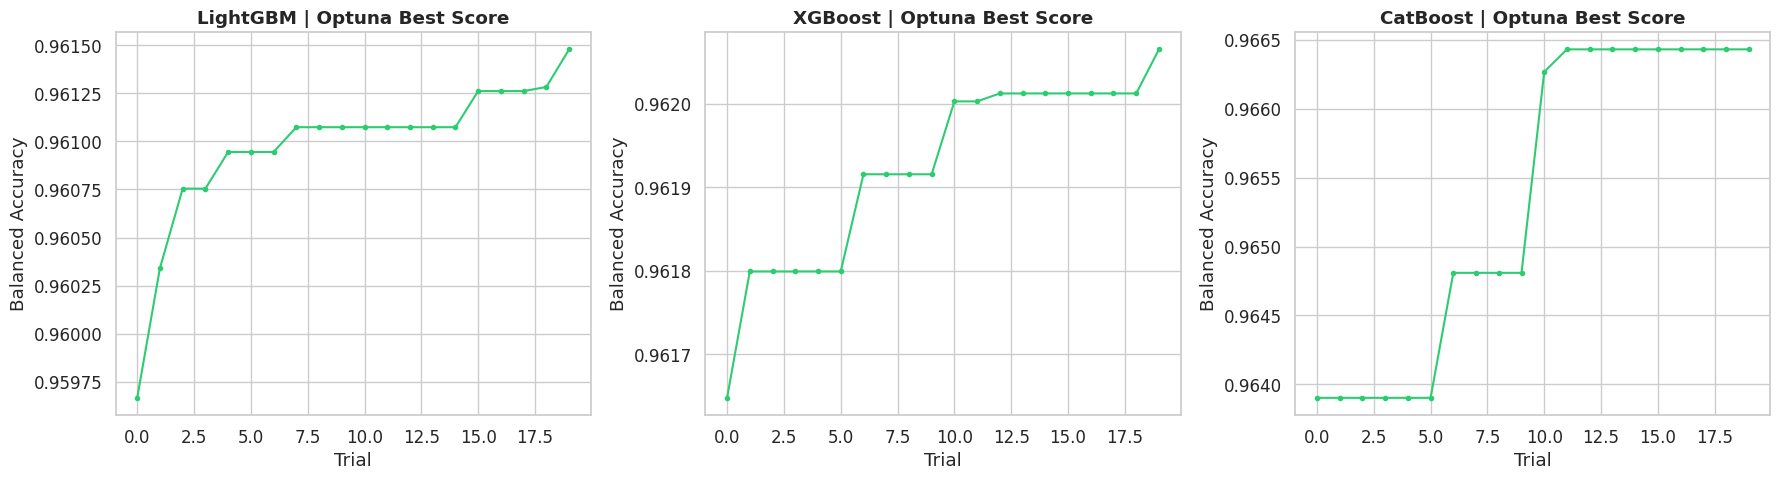

In [17]:
# Optuna convergence visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, study, name in zip(axes,
                            [study_lgbm, study_xgb, study_cat],
                            ["LightGBM", "XGBoost", "CatBoost"]):
    vals = [t.value for t in study.trials if t.value is not None]
    ax.plot(np.maximum.accumulate(vals), marker="o", markersize=3, linewidth=1.5)
    ax.set_title(f"{name} | Optuna Best Score", fontweight="bold")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Balanced Accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 9 | Full Training with Tuned Parameters

Each model is trained with the best parameters found by Optuna using 5-fold stratified cross-validation. OOF predictions are stored for ensembling.

Training LightGBM (5-fold CV) ...
  Fold 1/3 | Balanced Acc: 0.96181  (best iter: 657)
  Fold 2/3 | Balanced Acc: 0.96236  (best iter: 700)
  Fold 3/3 | Balanced Acc: 0.96191  (best iter: 656)
  Mean +/- Std: 0.96203 +/- 0.00024

LightGBM  |  OOF Balanced Accuracy = 0.96203

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.98      0.98    239074
        High       0.97      0.92      0.94     21009

    accuracy                           0.98    630000
   macro avg       0.98      0.96      0.97    630000
weighted avg       0.98      0.98      0.98    630000



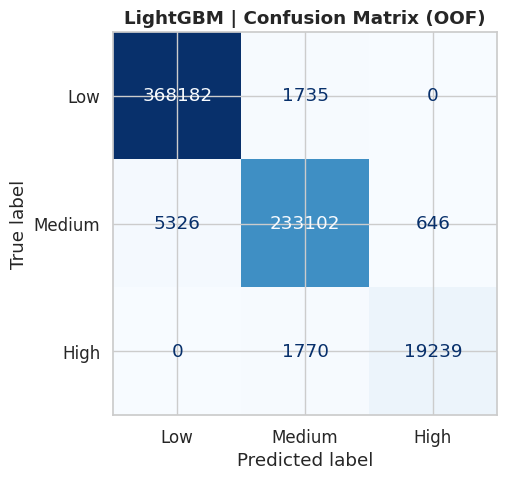


Training XGBoost (5-fold CV) ...
  Fold 1/3 | Balanced Acc: 0.96170
  Fold 2/3 | Balanced Acc: 0.96243
  Fold 3/3 | Balanced Acc: 0.96216
  Mean +/- Std: 0.96210 +/- 0.00030

XGBoost  |  OOF Balanced Accuracy = 0.96210

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074
        High       0.97      0.92      0.94     21009

    accuracy                           0.98    630000
   macro avg       0.98      0.96      0.97    630000
weighted avg       0.98      0.98      0.98    630000



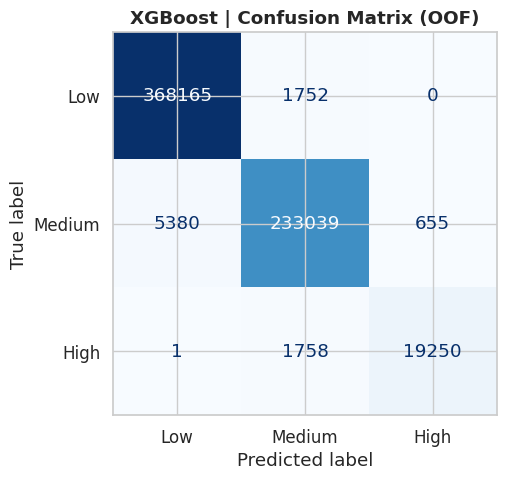


Training CatBoost (5-fold CV) ...
  Fold 1/3 | Balanced Acc: 0.96731
  Fold 2/3 | Balanced Acc: 0.96793
  Fold 3/3 | Balanced Acc: 0.96800
  Mean +/- Std: 0.96775 +/- 0.00031

CatBoost  |  OOF Balanced Accuracy = 0.96775

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99    369917
      Medium       0.98      0.96      0.97    239074
        High       0.85      0.95      0.90     21009

    accuracy                           0.98    630000
   macro avg       0.94      0.97      0.95    630000
weighted avg       0.98      0.98      0.98    630000



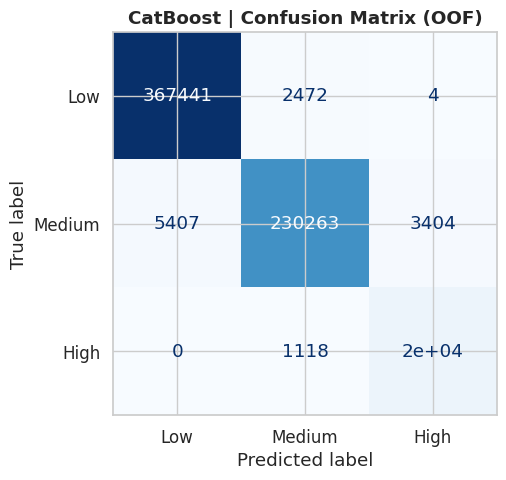

In [18]:
oof_lgbm, scores_lgbm = run_lgbm_cv(train_X, train_y, best_lgbm_params)
ba_lgbm = evaluate_oof(train_y, oof_lgbm, "LightGBM")

oof_xgb, scores_xgb = run_xgb_cv(train_X, train_y, best_xgb_params)
ba_xgb = evaluate_oof(train_y, oof_xgb, "XGBoost")

oof_cat, scores_cat = run_catboost_cv(train_X, train_y, best_cat_params)
ba_cat = evaluate_oof(train_y, oof_cat, "CatBoost")

---
## Section 10 | Ensembling

Three ensemble strategies are evaluated and compared:

| Strategy | Description |
|---|---|
| **Simple Average** | Unweighted mean of the three model OOF probability arrays |
| **Weighted Average** | Each model's weight is proportional to its OOF balanced accuracy |
| **Stacking** | Logistic Regression meta-learner trained on concatenated OOF probabilities |

In [19]:
# Simple average ensemble
oof_avg = (oof_lgbm + oof_xgb + oof_cat) / 3
ba_avg  = balanced_accuracy_score(train_y, np.argmax(oof_avg, axis=1))
print(f"Simple Average Ensemble   ->  Balanced Acc: {ba_avg:.5f}")

# Weighted average ensemble
scores  = np.array([ba_lgbm, ba_xgb, ba_cat])
weights = scores / scores.sum()
oof_wtd = (weights[0] * oof_lgbm + weights[1] * oof_xgb + weights[2] * oof_cat)
ba_wtd  = balanced_accuracy_score(train_y, np.argmax(oof_wtd, axis=1))
print(f"Weighted Average Ensemble ->  Balanced Acc: {ba_wtd:.5f}")
print(f"  Weights: LGBM={weights[0]:.3f}, XGB={weights[1]:.3f}, CAT={weights[2]:.3f}")

# Stacking meta-learner
from sklearn.linear_model import LogisticRegression

meta_features = np.hstack([oof_lgbm, oof_xgb, oof_cat])  # shape: (N, 9)
meta_model    = LogisticRegression(C=1.0, max_iter=500,
                                    class_weight="balanced",
                                    random_state=SEED, multi_class="auto")

oof_stack = np.zeros((len(train_y), 3))
for tr_idx, val_idx in SKF.split(meta_features, train_y):
    meta_model.fit(meta_features[tr_idx], train_y[tr_idx])
    oof_stack[val_idx] = meta_model.predict_proba(meta_features[val_idx])

ba_stack = balanced_accuracy_score(train_y, np.argmax(oof_stack, axis=1))
print(f"Stacking Ensemble         ->  Balanced Acc: {ba_stack:.5f}")

Simple Average Ensemble   ->  Balanced Acc: 0.96453
Weighted Average Ensemble ->  Balanced Acc: 0.96453
  Weights: LGBM=0.333, XGB=0.333, CAT=0.335
Stacking Ensemble         ->  Balanced Acc: 0.96905


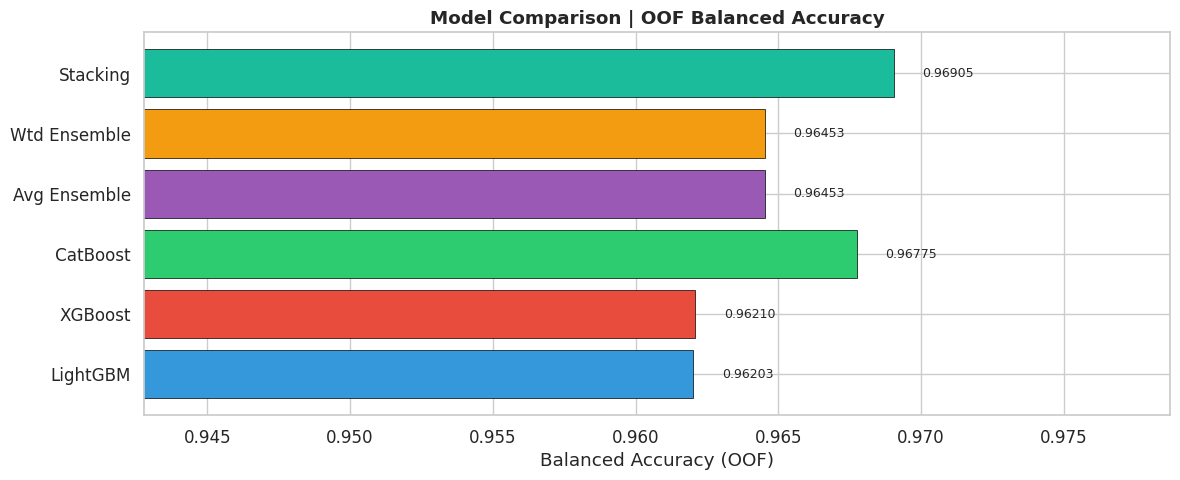


Best Ensemble Strategy: STACK | BA = 0.96905


In [20]:
# Model comparison bar chart
model_names  = ["LightGBM", "XGBoost", "CatBoost",
                "Avg Ensemble", "Wtd Ensemble", "Stacking"]
model_scores = [ba_lgbm, ba_xgb, ba_cat, ba_avg, ba_wtd, ba_stack]

colours = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c"]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(model_names, model_scores, color=colours, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Balanced Accuracy (OOF)")
ax.set_title("Model Comparison | OOF Balanced Accuracy", fontweight="bold")
ax.set_xlim(min(model_scores)*0.98, max(model_scores)*1.01)
for bar, score in zip(bars, model_scores):
    ax.text(score + 0.001, bar.get_y() + bar.get_height()/2,
            f"{score:.5f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Select best ensemble strategy
best_ba    = max(ba_avg, ba_wtd, ba_stack)
BEST_LABEL = {ba_avg: "avg", ba_wtd: "wtd", ba_stack: "stack"}[best_ba]
print(f"\nBest Ensemble Strategy: {BEST_LABEL.upper()} | BA = {best_ba:.5f}")

---
## Section 11 | Generate Test Predictions

Each model is retrained across all 5 folds on the training data. Test-set predictions are averaged across folds and then combined using the best ensemble strategy identified above.

In [22]:
def get_test_preds_lgbm(X_train, y_train, X_test, params):
    test_preds = np.zeros((len(X_test), 3))
    for fold, (tr_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        model  = lgb.train(params, dtrain, num_boost_round=5000,
                           valid_sets=[dval],
                           callbacks=[lgb.early_stopping(100, verbose=False),
                                      lgb.log_evaluation(period=-1)])
        test_preds += model.predict(X_test) / N_FOLDS
    return test_preds


def get_test_preds_xgb(X_train, y_train, X_test, params):
    test_preds = np.zeros((len(X_test), 3))
    for fold, (tr_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  verbose=False)
        test_preds += model.predict_proba(X_test) / N_FOLDS
    return test_preds


def get_test_preds_catboost(X_train, y_train, X_test, params):
    test_preds = np.zeros((len(X_test), 3))
    for fold, (tr_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  use_best_model=True, verbose=0)
        test_preds += model.predict_proba(X_test) / N_FOLDS
    return test_preds


print("Generating LightGBM test predictions ...")
test_lgbm = get_test_preds_lgbm(train_X, train_y, test_X, best_lgbm_params)

print("Generating XGBoost test predictions ...")
test_xgb  = get_test_preds_xgb(train_X, train_y, test_X, best_xgb_params)

print("Generating CatBoost test predictions ...")
test_cat  = get_test_preds_catboost(train_X, train_y, test_X, best_cat_params)

# Blend using the best ensemble strategy
if BEST_LABEL == "avg":
    test_final = (test_lgbm + test_xgb + test_cat) / 3
elif BEST_LABEL == "wtd":
    test_final = (weights[0]*test_lgbm + weights[1]*test_xgb + weights[2]*test_cat)
else:  # stacking
    meta_features_test = np.hstack([test_lgbm, test_xgb, test_cat])
    meta_model.fit(meta_features, train_y)
    test_final = meta_model.predict_proba(meta_features_test)

test_labels = [INV_MAP[c] for c in np.argmax(test_final, axis=1)]
print(f"\nTest prediction distribution: {pd.Series(test_labels).value_counts().to_dict()}")

Generating LightGBM test predictions ...
Generating XGBoost test predictions ...
Generating CatBoost test predictions ...

Test prediction distribution: {'Low': 159778, 'Medium': 100171, 'High': 10051}


---
## Section 12 | Submission

Construct the submission file in the required format and save it to disk.

In [23]:
submission = pd.DataFrame({
    "id"             : test["id"],
    "Irrigation_Need": test_labels,
})
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)

print("submission.csv saved.")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"Class distribution:\n{submission['Irrigation_Need'].value_counts()}")

submission.csv saved.
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008            High
9  630009             Low

Submission shape: (270000, 2)
Class distribution:
Irrigation_Need
Low       159778
Medium    100171
High       10051
Name: count, dtype: int64


---
## Section 13 | Bonus: Feature Importance.

### 13a | LightGBM Feature Importance

The full training set is used to retrain a single LightGBM model, and feature importances are ranked by **gain** (average information gain contributed by a feature across all splits).


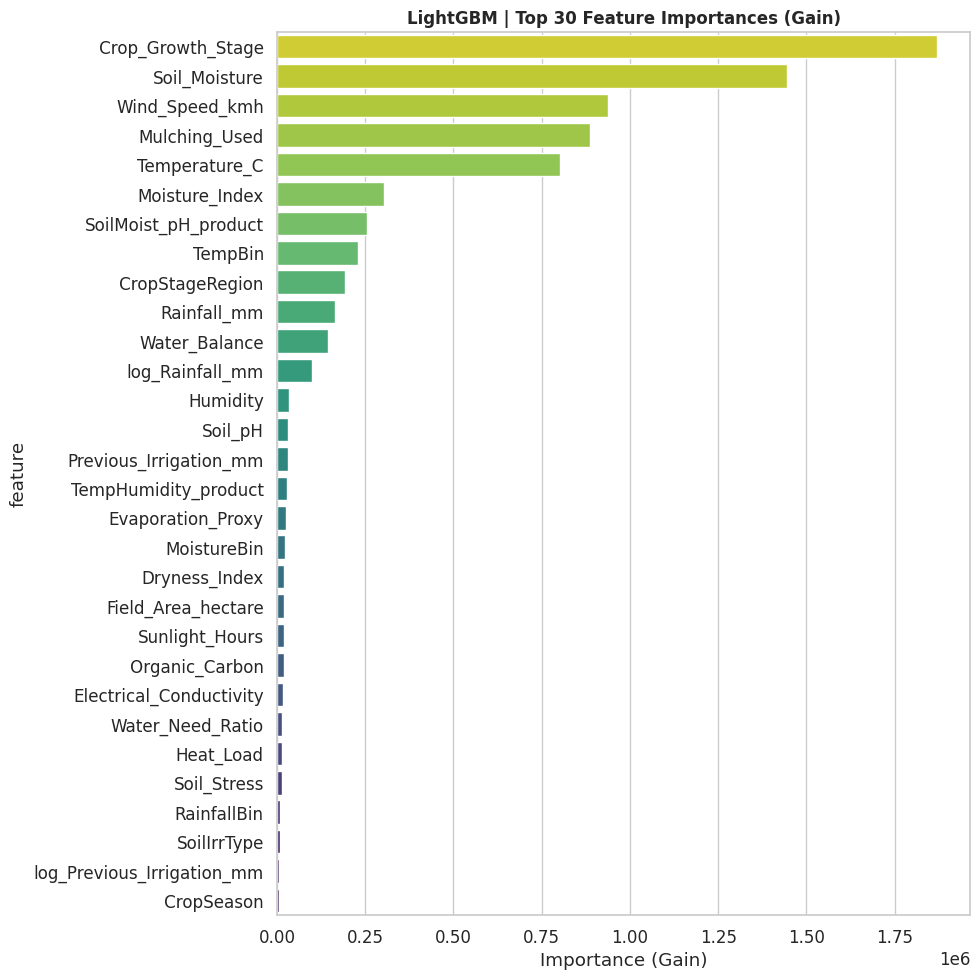


Top 10 features (Gain):
             feature   importance
   Crop_Growth_Stage 1.871138e+06
       Soil_Moisture 1.446153e+06
      Wind_Speed_kmh 9.388889e+05
       Mulching_Used 8.868746e+05
       Temperature_C 8.004804e+05
      Moisture_Index 3.033055e+05
SoilMoist_pH_product 2.538641e+05
             TempBin 2.298555e+05
     CropStageRegion 1.923552e+05
         Rainfall_mm 1.652341e+05


In [26]:
# 13-a  LightGBM feature importance (retrain on full data)
dtrain_full = lgb.Dataset(train_X, label=train_y)
lgbm_full   = lgb.train(best_lgbm_params, dtrain_full, num_boost_round=1000)

fi_df = pd.DataFrame({
    "feature"   : FEATURES,
    "importance": lgbm_full.feature_importance("gain"),
}).sort_values("importance", ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(data=fi_df, y="feature", x="importance", ax=ax,
            palette="viridis_r", orient="h")
ax.set_title("LightGBM | Top 30 Feature Importances (Gain)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Importance (Gain)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_feature_importance_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features (Gain):")
print(fi_df.head(10).to_string(index=False))